## Data Ingestion

### Importing required modules and libraries

In [6]:
# I/O & Visualization
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import itables
import io
import os
import urllib.parse
from dotenv import load_dotenv
from supabase import create_client
from sqlalchemy import create_engine




# Pre-processing 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Handle imbalance data
from imblearn.over_sampling import SMOTE

# Models
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier 
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Seaborn professional style
sns.set_style("whitegrid")

In [12]:
# 1. Load the environment variables from the .env file
load_dotenv()

# 2. Retrieve the credentials securely
USER = os.getenv("SUPABASE_USER")
PASSWORD = os.getenv("SUPABASE_PASSWORD")
HOST = os.getenv("SUPABASE_HOST")
PORT = os.getenv("SUPABASE_PORT")
DB_NAME = os.getenv("SUPABASE_DB_NAME")

# 3. URL-encode the password to safely handle the '@' symbol
safe_password = urllib.parse.quote_plus(PASSWORD)

# 4. Construct the connection string securely
DB_URI = f"postgresql://{USER}:{safe_password}@{HOST}:{PORT}/{DB_NAME}"

try:
    engine = create_engine(DB_URI)
    
    # Update with your actual table name
    query = "SELECT * FROM airline_fraud_data;" 
    
    df_raw = pd.read_sql(query, con=engine)
    print("Secure connection successful!")
    print(df.head())

except Exception as e:
    print(f"An error occurred: {e}")

Secure connection successful!
           transaction_date          payment_id           mrn     pnr  \
0 2025-01-01 11:39:56+00:00  09523W5AMVVWZ91ESZ  09523W5AMVVW  09523W   
1 2025-01-01 11:40:12+00:00  UHATHN5V9LOM98TE5O  UHATHN5V9LOM  UHATHN   
2 2025-01-01 11:40:13+00:00  ULFOCQ3UO39R9XZO37  ULFOCQ3UO39R  ULFOCQ   
3 2025-01-01 11:40:19+00:00  PQ3Z38HCM8GJ51Z6N4  PQ3Z38HCM8GJ  PQ3Z38   
4 2025-01-01 11:40:20+00:00  E478XNYDDLFBJYWOCA  E478XNYDDLFB  E478XN   

                    email_address      ip_address  \
0  2yqx4f2mtbi@tradedesk-corp.net   213.71.217.95   
1               fqo456m@gmail.com  91.200.238.163   
2              70y15ifd@gmail.com   113.75.70.245   
3       gkhdendl2t@protonmail.com  89.193.182.211   
4             4ap8b2rp3@gmail.com  228.232.43.152   

                          device_id    route  amount currency   card_type  \
0  e54927986d5e53f376b3b1dc9f3bd148  JFK-LHR  159.55      BRL    Discover   
1  26fe2c6001d40d98569510aa3e59a0bd  SIN-HKG  144.82      

### Importing the CSV dataset

### Previewing the dataset

In [13]:
# Making a copy of the original raw dataset
df = df_raw.copy()

In [14]:

print(f"Total rows in df: {len(df)}")

Total rows in df: 3000000


## Data Cleaning & Preprocessing

In [15]:
# Converting card_last_4 to dtype 'str' as we have 0 values at the start which otherwise wouldn't reflect if dtype is 'int'
df['card_last_4'] = df['card_last_4'].astype(str).str.zfill(4)

In [16]:
# Handling Missing Values in loyalty_tier column
df['loyalty_tier'] = df['loyalty_tier'].fillna('None')

In [17]:
# Converting the 'transaction_date' column data type to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

In [18]:
print(df.head(5))

           transaction_date          payment_id           mrn     pnr  \
0 2025-01-01 11:39:56+00:00  09523W5AMVVWZ91ESZ  09523W5AMVVW  09523W   
1 2025-01-01 11:40:12+00:00  UHATHN5V9LOM98TE5O  UHATHN5V9LOM  UHATHN   
2 2025-01-01 11:40:13+00:00  ULFOCQ3UO39R9XZO37  ULFOCQ3UO39R  ULFOCQ   
3 2025-01-01 11:40:19+00:00  PQ3Z38HCM8GJ51Z6N4  PQ3Z38HCM8GJ  PQ3Z38   
4 2025-01-01 11:40:20+00:00  E478XNYDDLFBJYWOCA  E478XNYDDLFB  E478XN   

                    email_address      ip_address  \
0  2yqx4f2mtbi@tradedesk-corp.net   213.71.217.95   
1               fqo456m@gmail.com  91.200.238.163   
2              70y15ifd@gmail.com   113.75.70.245   
3       gkhdendl2t@protonmail.com  89.193.182.211   
4             4ap8b2rp3@gmail.com  228.232.43.152   

                          device_id    route  amount currency   card_type  \
0  e54927986d5e53f376b3b1dc9f3bd148  JFK-LHR  159.55      BRL    Discover   
1  26fe2c6001d40d98569510aa3e59a0bd  SIN-HKG  144.82      GBP        Visa   
2  0cb2518e

## Exploratory Data Analysis

In [19]:
# Checking the ratio of fraud vs non-fraud distribution
df.is_fraud.value_counts(normalize=True)*100

is_fraud
0    98.509533
1     1.490467
Name: proportion, dtype: float64

The dataset has an overall fraud rate of 1.49%

In [20]:
# Define exchange rates relative to 1 USD (Updated exchange rates relative to 1 USD (June 2026))
exchange_rates = {
    'USD': 1.00,
    'GBP': 0.76,
    'EUR': 0.88,
    'INR': 94.67,
    'AED': 3.67,
    'SGD': 1.30,
    'AUD': 1.45,
    'CNY': 6.78,
    'QAR': 3.64,
    'CAD': 1.42,
    'JPY': 161.76,
    'BRL': 5.20,
    'ZAR': 16.61,
    'TRY': 46.49,
    'HKD': 7.80,
    'KRW': 1546.43
}

# Map exchange rates and calculate a standardized USD amount
# We divide the native amount by the currency's rate to normalize it to USD
df['fx_rate'] = df['currency'].map(exchange_rates)
df['amount_usd'] = df['amount'] / df['fx_rate']

Downsampling the data to avoid kernal crash as aggregating the 'amount' column is very resource intensive 

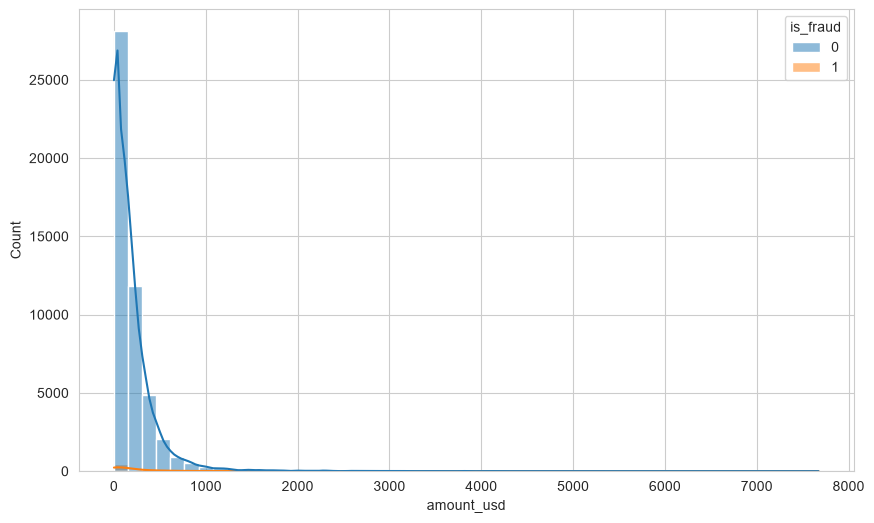

In [21]:
# Strategic Downsampling
# Taking a random sample of 50,000 rows to protect system memory or avoid kernal crash
df_sample = df.sample(n=50000, random_state=22)

# Plotting the cleaned, normalized distribution
plt.figure(figsize=(10,6))

sns.histplot(
    data=df_sample, 
    x='amount_usd',
    hue='is_fraud', 
    kde=True, 
    bins=50
)

plt.show()

### Calculating actual revenue loss after normalizing the currencies

In [22]:
total_txn_amt = df['amount_usd'].sum()
print(f"Sum of total transaction amount in USD: {total_txn_amt:,.2f}")
fraud_total_amt = df.query("is_fraud == 1")['amount'].sum()
print(f"Sum of total fraud amount in USD: {fraud_total_amt:,.2f}")

fraud_perc_amt = fraud_total_amt * 100 / total_txn_amt
print(f"Percentage of revenue loss: {fraud_perc_amt:,.2f}%")

Sum of total transaction amount in USD: 578,806,359.97
Sum of total fraud amount in USD: 16,238,750.51
Percentage of revenue loss: 2.81%


### Categorical Risk Profiles

In [23]:
# Aggregate the counts and sums
risk_profile = df.groupby(['card_type', 'bin_country', 'bank_name']).agg(
    total_transactions=('is_fraud', 'count'),    # Total number of rows
    fraud_transactions=('is_fraud', 'sum')       # Total number of 1s
).reset_index()

# Calculate the fraud rate manually
risk_profile['fraud_rate'] = (risk_profile['fraud_transactions'] / risk_profile['total_transactions']).round(3)

# Sort to find the most dangerous combinations at the top
risk_profile = risk_profile.sort_values(by='fraud_rate', ascending=False)

# Let's peek at the top 10 riskiest combinations
print(risk_profile.head(10))

      card_type bin_country            bank_name  total_transactions  \
2   Diners Club          US     Diners Club Intl               27792   
12        RuPay          IN  State Bank of India               83070   
18         Visa          IN           ICICI Bank              125630   
1          Amex          US     American Express              167237   
7    MasterCard          FR          BNP Paribas               97474   
6    MasterCard          DE        Deutsche Bank              111594   
3      Discover          US   Discover Financial               83236   
4    MasterCard          AE         Emirates NBD               55272   
20         Visa          SG             DBS Bank               69185   
22         Visa          US                Chase              389158   

    fraud_transactions  fraud_rate  
2                  446       0.016  
12                1311       0.016  
18                1962       0.016  
1                 2456       0.015  
7                 1501

In [24]:
# Extracting the hour from date column
df['transaction_hour'] = df['transaction_date'].dt.hour

### Checking for fraud spikes during odd hours

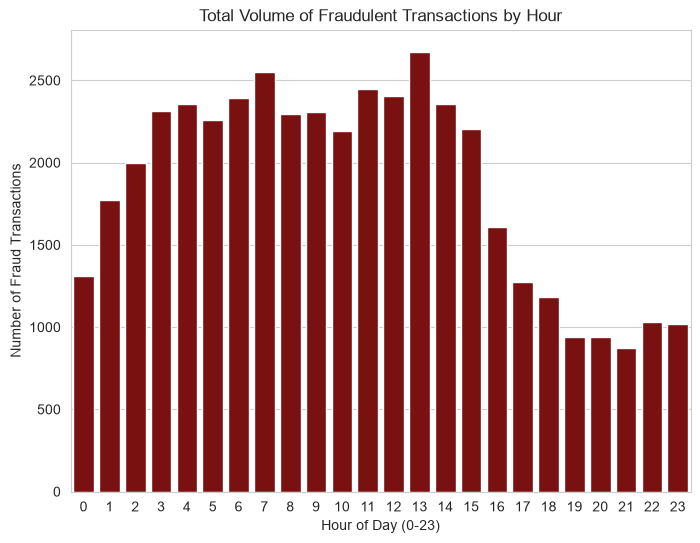

In [25]:
plt.figure(figsize=(8,6))

fraud_txns = df[df['is_fraud'] == 1]

sns.countplot(
    x='transaction_hour',
    data=fraud_txns,
    color='darkred'
)

plt.title('Total Volume of Fraudulent Transactions by Hour')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Number of Fraud Transactions')
plt.show()

Observation: No unusual spikes are visible during odd or midnight hours

## Feature Engineering

In [26]:
df_copy = df.copy()

In [27]:
itables.show(df_copy)

Loading ITables v2.8.1 from the internet... (need help?)


In [28]:
df_copy = df_copy.sort_values(by=['ip_address', 'transaction_date']).reset_index(drop=True)

df_copy['iptxn_1hr'] = (df_copy.groupby('ip_address')
                   .rolling(window='1h', on='transaction_date')['is_fraud']
                   .count()
                   .values)